In [1]:
# Import all required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import (mean_absolute_error, 
                             mean_squared_error, 
                             r2_score)
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings('ignore')

print("✅ All libraries imported successfully!")

✅ All libraries imported successfully!


### Load Dataset

In [2]:
# Load Advertising dataset directly from URL
# Dataset: Advertising spend vs Sales
url = "https://raw.githubusercontent.com/selva86/datasets/master/Advertising.csv"
df = pd.read_csv(url, index_col=0)

print("✅ Dataset loaded successfully!")
print(f"Shape: {df.shape[0]} rows × {df.shape[1]} columns")
print(f"\nColumns: {df.columns.tolist()}")
print(f"\nFirst 5 rows:")
df.head()

✅ Dataset loaded successfully!
Shape: 200 rows × 4 columns

Columns: ['TV', 'radio', 'newspaper', 'sales']

First 5 rows:


,TV,radio,newspaper,sales
1,230.1,37.8,69.2,22.1
2,44.5,39.3,45.1,10.4
3,17.2,45.9,69.3,9.3
4,151.5,41.3,58.5,18.5
5,180.8,10.8,58.4,12.9


### Dataset Overview

In [3]:
print("=" * 50)
print("DATASET OVERVIEW")
print("=" * 50)

print("\n📌 Basic Info:")
print(df.info())

print("\n📌 Statistical Summary:")
print(df.describe().round(2))

print(f"\n📌 Missing Values: {df.isnull().sum().sum()}")
print("✅ No missing values — dataset is clean!")

DATASET OVERVIEW

📌 Basic Info:
<class 'pandas.DataFrame'>
RangeIndex: 200 entries, 1 to 200
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   TV         200 non-null    float64
 1   radio      200 non-null    float64
 2   newspaper  200 non-null    float64
 3   sales      200 non-null    float64
dtypes: float64(4)
memory usage: 6.4 KB
None

📌 Statistical Summary:
           TV   radio  newspaper   sales
count  200.00  200.00     200.00  200.00
mean   147.04   23.26      30.55   14.02
std     85.85   14.85      21.78    5.22
min      0.70    0.00       0.30    1.60
25%     74.38    9.98      12.75   10.38
50%    149.75   22.90      25.75   12.90
75%    218.82   36.52      45.10   17.40
max    296.40   49.60     114.00   27.00

📌 Missing Values: 0
✅ No missing values — dataset is clean!


### Exploratory Data Analysis

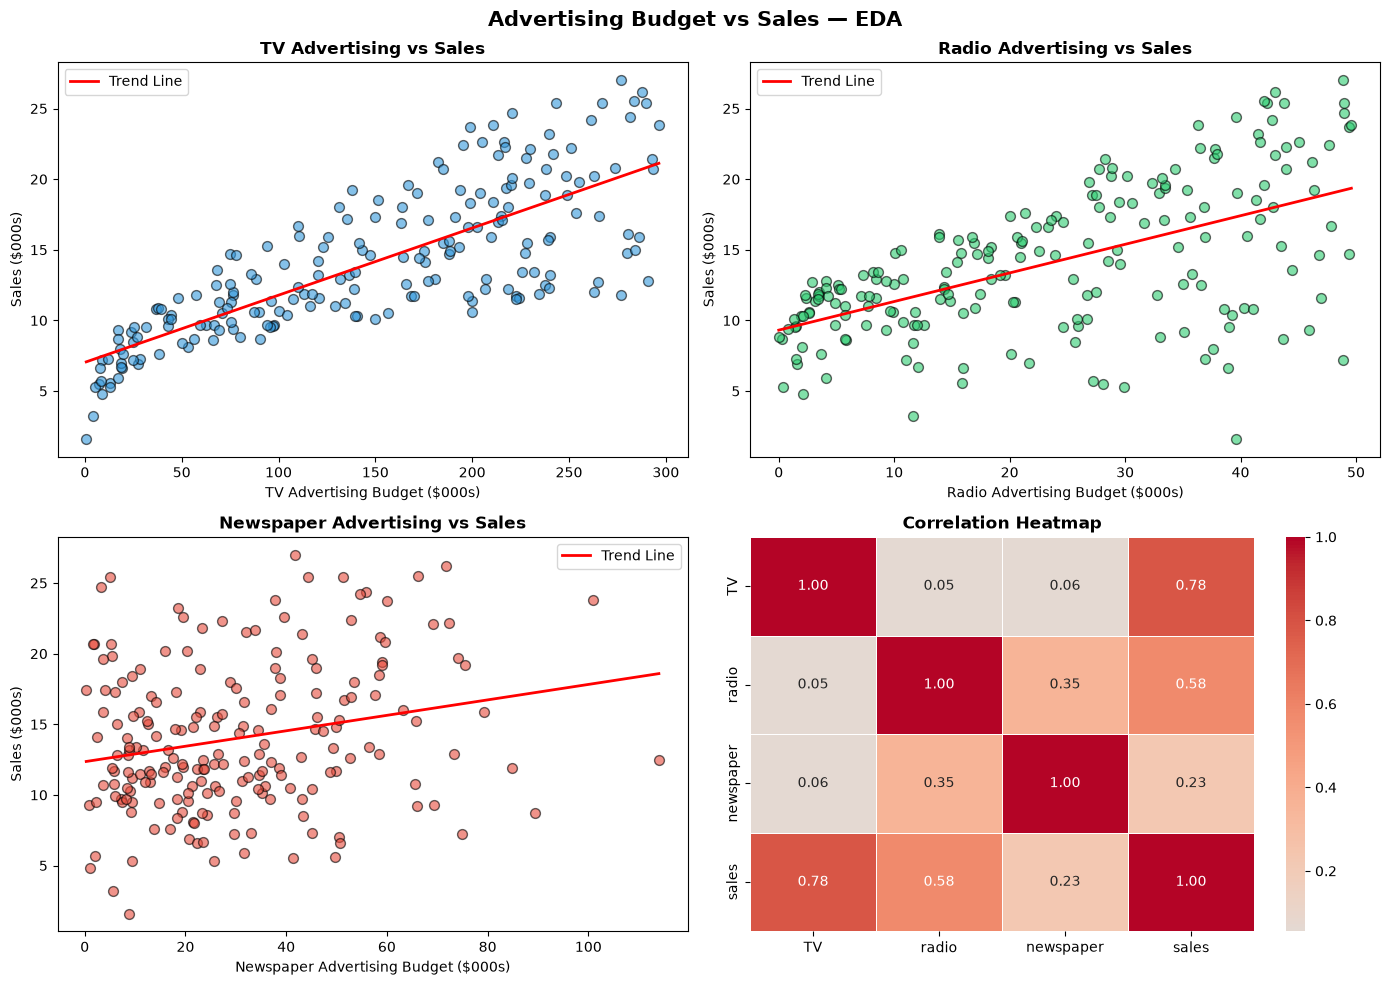

✅ EDA chart saved!

📊 Correlation with Sales:
sales        1.000000
TV           0.782224
radio        0.576223
newspaper    0.228299


In [4]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# TV vs Sales
axes[0,0].scatter(df['TV'], df['sales'], 
                  color='#3498DB', alpha=0.6, edgecolor='black', s=50)
axes[0,0].set_title('TV Advertising vs Sales', fontsize=12, fontweight='bold')
axes[0,0].set_xlabel('TV Advertising Budget ($000s)')
axes[0,0].set_ylabel('Sales ($000s)')

# Add trend line
z = np.polyfit(df['TV'], df['sales'], 1)
p = np.poly1d(z)
axes[0,0].plot(sorted(df['TV']), p(sorted(df['TV'])), 
               color='red', linewidth=2, label='Trend Line')
axes[0,0].legend()

# Radio vs Sales
axes[0,1].scatter(df['radio'], df['sales'], 
                  color='#2ECC71', alpha=0.6, edgecolor='black', s=50)
axes[0,1].set_title('Radio Advertising vs Sales', fontsize=12, fontweight='bold')
axes[0,1].set_xlabel('Radio Advertising Budget ($000s)')
axes[0,1].set_ylabel('Sales ($000s)')

z2 = np.polyfit(df['radio'], df['sales'], 1)
p2 = np.poly1d(z2)
axes[0,1].plot(sorted(df['radio']), p2(sorted(df['radio'])), 
               color='red', linewidth=2, label='Trend Line')
axes[0,1].legend()

# Newspaper vs Sales
axes[1,0].scatter(df['newspaper'], df['sales'], 
                  color='#E74C3C', alpha=0.6, edgecolor='black', s=50)
axes[1,0].set_title('Newspaper Advertising vs Sales', fontsize=12, fontweight='bold')
axes[1,0].set_xlabel('Newspaper Advertising Budget ($000s)')
axes[1,0].set_ylabel('Sales ($000s)')

z3 = np.polyfit(df['newspaper'], df['sales'], 1)
p3 = np.poly1d(z3)
axes[1,0].plot(sorted(df['newspaper']), p3(sorted(df['newspaper'])), 
               color='red', linewidth=2, label='Trend Line')
axes[1,0].legend()

# Correlation Heatmap
corr = df.corr()
sns.heatmap(corr, annot=True, fmt='.2f', 
            cmap='coolwarm', center=0,
            ax=axes[1,1], linewidths=0.5)
axes[1,1].set_title('Correlation Heatmap', fontsize=12, fontweight='bold')

plt.suptitle('Advertising Budget vs Sales — EDA', 
             fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('advertising_eda.png', dpi=150)
plt.show()

print("✅ EDA chart saved!")
print(f"\n📊 Correlation with Sales:")
print(df.corr()['sales'].sort_values(ascending=False).to_string())

### Feature Selection & Split

In [5]:
print("=" * 50)
print("FEATURE SELECTION & DATA SPLITTING")
print("=" * 50)

# Use TV advertising as main feature (highest correlation)
# You can also use all 3 features — shown below

# Option A: Simple Linear Regression (TV only)
X_simple = df[['TV']]
y = df['sales']

# Option B: Multiple Linear Regression (all features)
X_multi = df[['TV', 'radio', 'newspaper']]

# Split both
X_train_s, X_test_s, y_train, y_test = train_test_split(
    X_simple, y, test_size=0.2, random_state=42)

X_train_m, X_test_m, _, _ = train_test_split(
    X_multi, y, test_size=0.2, random_state=42)

print(f"✅ Simple LR  — Feature: TV only")
print(f"✅ Multiple LR — Features: TV + Radio + Newspaper")
print(f"\nTrain samples: {X_train_s.shape[0]}")
print(f"Test samples:  {X_test_s.shape[0]}")

FEATURE SELECTION & DATA SPLITTING
✅ Simple LR  — Feature: TV only
✅ Multiple LR — Features: TV + Radio + Newspaper

Train samples: 160
Test samples:  40


### Build & Train Both Models

In [6]:
print("=" * 50)
print("BUILDING LINEAR REGRESSION MODELS")
print("=" * 50)

# Simple Linear Regression
model_simple = LinearRegression()
model_simple.fit(X_train_s, y_train)
y_pred_simple = model_simple.predict(X_test_s)

# Multiple Linear Regression
model_multi = LinearRegression()
model_multi.fit(X_train_m, y_train)
y_pred_multi = model_multi.predict(X_test_m)

# Metrics
def get_metrics(y_test, y_pred, model_name):
    mae  = mean_absolute_error(y_test, y_pred)
    mse  = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    r2   = r2_score(y_test, y_pred)
    print(f"\n📊 {model_name}:")
    print(f"   MAE  (Mean Absolute Error):  {mae:.3f}")
    print(f"   MSE  (Mean Squared Error):   {mse:.3f}")
    print(f"   RMSE (Root MSE):             {rmse:.3f}")
    print(f"   R²   (R-Squared Score):      {r2:.3f} ({r2*100:.1f}% variance explained)")
    return mae, mse, rmse, r2

mae_s, mse_s, rmse_s, r2_s = get_metrics(
    y_test, y_pred_simple, "Simple Linear Regression (TV only)")

mae_m, mse_m, rmse_m, r2_m = get_metrics(
    y_test, y_pred_multi, "Multiple Linear Regression (TV+Radio+Newspaper)")

print(f"\n✅ Models trained successfully!")

BUILDING LINEAR REGRESSION MODELS

📊 Simple Linear Regression (TV only):
   MAE  (Mean Absolute Error):  2.444
   MSE  (Mean Squared Error):   10.205
   RMSE (Root MSE):             3.194
   R²   (R-Squared Score):      0.677 (67.7% variance explained)

📊 Multiple Linear Regression (TV+Radio+Newspaper):
   MAE  (Mean Absolute Error):  1.461
   MSE  (Mean Squared Error):   3.174
   RMSE (Root MSE):             1.782
   R²   (R-Squared Score):      0.899 (89.9% variance explained)

✅ Models trained successfully!


 ### Visualise Regression Line

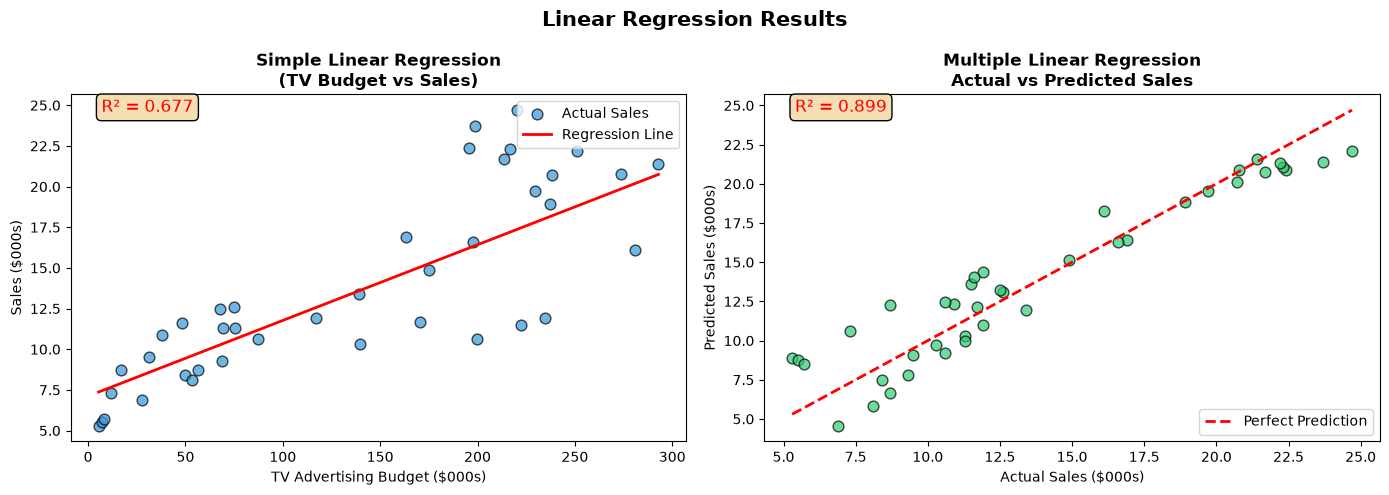

✅ Regression results chart saved!


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Simple LR — Actual vs Predicted
axes[0].scatter(X_test_s, y_test, 
                color='#3498DB', alpha=0.7, 
                label='Actual Sales', s=60, edgecolor='black')
axes[0].plot(sorted(X_test_s['TV']), 
             model_simple.predict(pd.DataFrame(
                 sorted(X_test_s['TV']), columns=['TV'])),
             color='red', linewidth=2, label='Regression Line')
axes[0].set_title('Simple Linear Regression\n(TV Budget vs Sales)', 
                  fontsize=12, fontweight='bold')
axes[0].set_xlabel('TV Advertising Budget ($000s)')
axes[0].set_ylabel('Sales ($000s)')
axes[0].legend()
axes[0].text(0.05, 0.95, f'R² = {r2_s:.3f}',
             transform=axes[0].transAxes,
             fontsize=12, color='red',
             bbox=dict(boxstyle='round', facecolor='wheat'))

# Multiple LR — Actual vs Predicted
axes[1].scatter(y_test, y_pred_multi, 
                color='#2ECC71', alpha=0.7, 
                edgecolor='black', s=60)
axes[1].plot([y_test.min(), y_test.max()], 
             [y_test.min(), y_test.max()],
             color='red', linewidth=2, 
             linestyle='--', label='Perfect Prediction')
axes[1].set_title('Multiple Linear Regression\nActual vs Predicted Sales', 
                  fontsize=12, fontweight='bold')
axes[1].set_xlabel('Actual Sales ($000s)')
axes[1].set_ylabel('Predicted Sales ($000s)')
axes[1].legend()
axes[1].text(0.05, 0.95, f'R² = {r2_m:.3f}',
             transform=axes[1].transAxes,
             fontsize=12, color='red',
             bbox=dict(boxstyle='round', facecolor='wheat'))

plt.suptitle('Linear Regression Results', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('regression_results.png', dpi=150)
plt.show()
print("✅ Regression results chart saved!")

### Residual Analysis

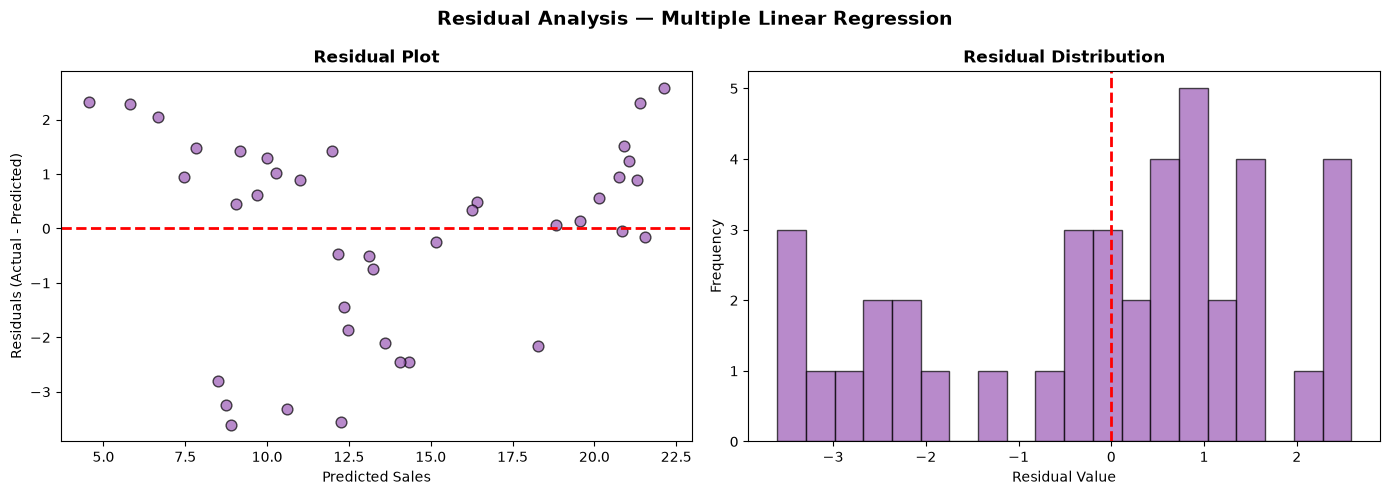

✅ Residual analysis chart saved!


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Residuals for Multiple LR
residuals = y_test - y_pred_multi

# Residual Plot
axes[0].scatter(y_pred_multi, residuals,
                color='#9B59B6', alpha=0.7,
                edgecolor='black', s=60)
axes[0].axhline(y=0, color='red', 
                linestyle='--', linewidth=2)
axes[0].set_title('Residual Plot', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Predicted Sales')
axes[0].set_ylabel('Residuals (Actual - Predicted)')

# Residual Distribution
axes[1].hist(residuals, bins=20, 
             color='#9B59B6', edgecolor='black', alpha=0.7)
axes[1].axvline(x=0, color='red', 
                linestyle='--', linewidth=2)
axes[1].set_title('Residual Distribution', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Residual Value')
axes[1].set_ylabel('Frequency')

plt.suptitle('Residual Analysis — Multiple Linear Regression',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('residual_analysis.png', dpi=150)
plt.show()
print("✅ Residual analysis chart saved!")

### Model Coefficients

MODEL COEFFICIENTS — MULTIPLE LINEAR REGRESSION

Intercept: 2.979

Coefficients:
   Radio       : 0.1892
   → Every $1,000 increase in Radio ads = 189 units increase in sales
   TV          : 0.0447
   → Every $1,000 increase in TV ads = 45 units increase in sales
   Newspaper   : 0.0028
   → Every $1,000 increase in Newspaper ads = 3 units increase in sales


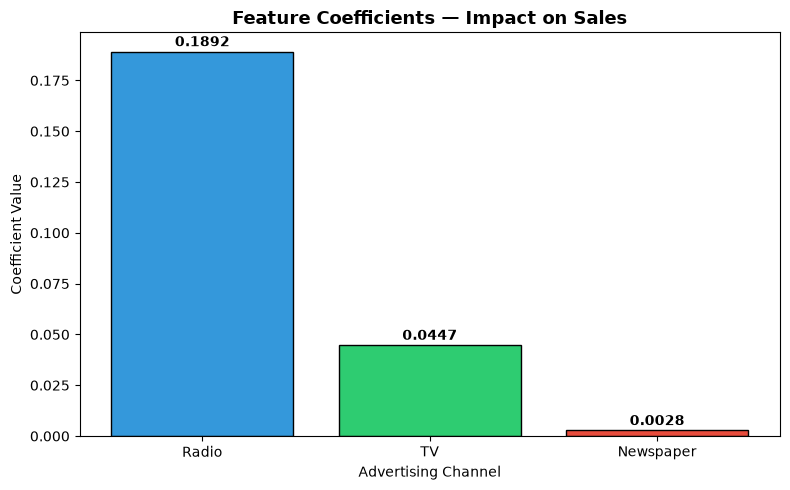

✅ Coefficients chart saved!


In [9]:
print("=" * 50)
print("MODEL COEFFICIENTS — MULTIPLE LINEAR REGRESSION")
print("=" * 50)

coef_df = pd.DataFrame({
    'Feature': ['TV', 'Radio', 'Newspaper'],
    'Coefficient': model_multi.coef_
}).sort_values('Coefficient', ascending=False)

print(f"\nIntercept: {model_multi.intercept_:.3f}")
print("\nCoefficients:")
for _, row in coef_df.iterrows():
    print(f"   {row['Feature']:12s}: {row['Coefficient']:.4f}")
    print(f"   → Every $1,000 increase in {row['Feature']} ads = "
          f"{row['Coefficient']*1000:.0f} units increase in sales")

# Bar chart of coefficients
plt.figure(figsize=(8, 5))
colors = ['#3498DB', '#2ECC71', '#E74C3C']
bars = plt.bar(coef_df['Feature'], coef_df['Coefficient'],
               color=colors, edgecolor='black')
plt.title('Feature Coefficients — Impact on Sales',
          fontsize=13, fontweight='bold')
plt.xlabel('Advertising Channel')
plt.ylabel('Coefficient Value')

for bar, val in zip(bars, coef_df['Coefficient']):
    plt.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 0.001,
             f'{val:.4f}',
             ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.savefig('coefficients.png', dpi=150)
plt.show()
print("✅ Coefficients chart saved!")

### Final Summary

In [10]:
print("=" * 60)
print("   PROJECT 2 — FINAL SUMMARY & CONCLUSIONS")
print("=" * 60)

print(f"""
📌 DATASET
   Source:     Advertising dataset (200 records)
   Features:   TV, Radio, Newspaper advertising budgets
   Target:     Sales figures

📌 MODEL COMPARISON
   ┌─────────────────────────────┬────────┬────────┐
   │ Model                       │  R²    │  RMSE  │
   ├─────────────────────────────┼────────┼────────┤
   │ Simple LR (TV only)         │ {r2_s:.3f}  │ {rmse_s:.3f}  │
   │ Multiple LR (TV+Radio+News) │ {r2_m:.3f}  │ {rmse_m:.3f}  │
   └─────────────────────────────┴────────┴────────┘

📌 KEY FINDINGS
   1. TV advertising has the strongest impact on sales
      (correlation = {df.corr()['sales']['TV']:.2f})

   2. Radio advertising is the 2nd most effective channel
      (correlation = {df.corr()['sales']['radio']:.2f})

   3. Newspaper advertising has the weakest impact
      (correlation = {df.corr()['sales']['newspaper']:.2f})

   4. Multiple LR explains {r2_m*100:.1f}% of sales variance
      → A good model for sales prediction

📌 BUSINESS INSIGHT
   → Invest more in TV and Radio advertising
   → Newspaper ads have minimal ROI on sales

📌 FILES SAVED
   ✅ advertising_eda.png
   ✅ regression_results.png
   ✅ residual_analysis.png
   ✅ coefficients.png

✅ Project 2 Complete!
""")

   PROJECT 2 — FINAL SUMMARY & CONCLUSIONS

📌 DATASET
   Source:     Advertising dataset (200 records)
   Features:   TV, Radio, Newspaper advertising budgets
   Target:     Sales figures

📌 MODEL COMPARISON
   ┌─────────────────────────────┬────────┬────────┐
   │ Model                       │  R²    │  RMSE  │
   ├─────────────────────────────┼────────┼────────┤
   │ Simple LR (TV only)         │ 0.677  │ 3.194  │
   │ Multiple LR (TV+Radio+News) │ 0.899  │ 1.782  │
   └─────────────────────────────┴────────┴────────┘

📌 KEY FINDINGS
   1. TV advertising has the strongest impact on sales
      (correlation = 0.78)

   2. Radio advertising is the 2nd most effective channel
      (correlation = 0.58)

   3. Newspaper advertising has the weakest impact
      (correlation = 0.23)

   4. Multiple LR explains 89.9% of sales variance
      → A good model for sales prediction

📌 BUSINESS INSIGHT
   → Invest more in TV and Radio advertising
   → Newspaper ads have minimal ROI on sales

📌 FILE